# Strict-Full vs Strict CatBoost Ablation with pAUC@88

이 notebook은 `Strict-Full (초기 Strict 후보)`와 `Strict (최종 메인 세트)`를 CatBoost로 비교하고, `Strict-Full`에만 남아 있는 추가 feature들이 실제로 도움이 되는지 ablation 방식으로 점검하기 위한 notebook이다.

## 실험 목적
1. `Strict-Full`과 `Strict`를 동일한 CatBoost 설정에서 비교한다.
2. 기본 평가지표는 `pAUC@TPR>=0.88`로 둔다.
3. `Strict-Full`의 추가 feature가 높은 민감도 구간에서 실제로 이득인지 다시 확인한다.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings('ignore')

FONT_CANDIDATES = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
]
for font_path in FONT_CANDIDATES:
    if Path(font_path).exists():
        from matplotlib import font_manager as fm
        font_name = fm.FontProperties(fname=font_path).get_name()
        mpl.rcParams['font.family'] = font_name
        break
mpl.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

base_dir = Path('/home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024')
input_dir = base_dir / 'model_inputs'
out_dir = base_dir / 'modeling' / 'strict_full_vs_final_strict_catboost_ablation'
out_dir.mkdir(parents=True, exist_ok=True)

PRIMARY_MIN_TPR = 0.88
SECONDARY_MIN_TPR = 0.80
PRIMARY_MAX_FPR = 1 - PRIMARY_MIN_TPR
DISPLAY_NAME = {
    'strict_full': 'Strict-Full',
    'strict_full_ablation': 'Strict-Full ablation',
    'final_strict': 'Strict',
}
DISPLAY_COLOR = {
    'strict_full': '#d55e00',
    'final_strict': '#0072b2',
}

strict_full_paths = {
    'train': input_dir / 'isic2024_strict_train_input.parquet',
    'validation': input_dir / 'isic2024_strict_validation_input.parquet',
    'internal_test': input_dir / 'isic2024_strict_internal_test_input.parquet',
}
final_strict_paths = {
    'train': input_dir / 'isic2024_final_strict_train_input.parquet',
    'validation': input_dir / 'isic2024_final_strict_validation_input.parquet',
    'internal_test': input_dir / 'isic2024_final_strict_internal_test_input.parquet',
}
manifest_path = input_dir / 'strict_full_vs_final_strict_feature_manifest.json'
meta_cols = ['isic_id', 'patient_id', 'target', 'split']
random_state = 42

manifest = json.loads(manifest_path.read_text())
strict_full_feature_columns = manifest['strict_feature_columns']
final_strict_feature_columns = manifest['final_strict_feature_columns']
strict_only_features = sorted(set(strict_full_feature_columns) - set(final_strict_feature_columns))

catboost_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'depth': 6,
    'learning_rate': 0.05,
    'iterations': 400,
    'random_seed': random_state,
    'verbose': False,
    'auto_class_weights': 'Balanced',
}

print('primary metric = pAUC@TPR>=', PRIMARY_MIN_TPR)


primary metric = pAUC@TPR>= 0.88


## 1. 입력 테이블과 Strict-Full 전용 feature 목록 확인

### 목적
코드 셀에서는 `Strict-Full`, `Strict` 입력 테이블을 읽고, `Strict-Full`에만 존재하는 추가 feature 11개를 확인합니다.

이 11개가 이번 ablation의 핵심 대상입니다.


In [2]:
strict_full_data = {split: pd.read_parquet(path) for split, path in strict_full_paths.items()}
final_strict_data = {split: pd.read_parquet(path) for split, path in final_strict_paths.items()}

summary_rows = []
for regime_name, regime_data in [('strict_full', strict_full_data), ('final_strict', final_strict_data)]:
    for split, df in regime_data.items():
        feature_cols = [c for c in df.columns if c not in meta_cols]
        summary_rows.append({
            'regime': regime_name,
            'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
            'split': split,
            'n_rows': len(df),
            'n_feature_columns': len(feature_cols),
            'n_positive_rows': int(df['target'].sum()),
            'positive_ratio_pct': round(df['target'].mean() * 100, 6),
        })
summary_df = pd.DataFrame(summary_rows)
display(summary_df[['regime_display', 'split', 'n_rows', 'n_feature_columns', 'n_positive_rows', 'positive_ratio_pct']])

display(pd.DataFrame({'strict_full_only_feature': strict_only_features}))


,regime_display,split,n_rows,n_feature_columns,n_positive_rows,positive_ratio_pct
0,Strict-Full,train,280335,62,270,0.096313
1,Strict-Full,validation,65684,62,57,0.086779
2,Strict-Full,internal_test,55040,62,66,0.119913
3,Strict,train,280335,51,270,0.096313
4,Strict,validation,65684,51,57,0.086779
5,Strict,internal_test,55040,51,66,0.119913


,strict_full_only_feature
0,feat_age_contrast_interaction
1,feat_color_to_border_ratio
2,feat_contrast_to_color_variation
3,feat_diameter_symmetry_coupling
4,feat_hue_circular_gap
5,feat_long_to_minor_ratio
6,feat_nevi_border_interaction
7,feat_perimeter_to_long_ratio
8,feat_red_green_normalized_gap
9,feat_symmetry_contrast_interaction


### 해석 포인트
1. 두 입력 세트는 같은 split, 같은 샘플을 가져야 합니다.
2. 차이는 `Strict-Full`에만 있는 추가 feature 11개뿐이어야 합니다.
3. 따라서 이후 비교는 `이 추가 feature들을 유지할 가치가 있는가`라는 질문에 직접 연결됩니다.


## 2. CatBoost용 공통 함수 정의

### 목적
코드 셀에서는 `Strict-Full`, `Strict`, 그리고 각 ablation 실험에 공통으로 쓰일 학습/평가 함수를 정의합니다.

이번 평가는 다음 원칙을 따릅니다.
1. 학습은 `train`만 사용합니다.
2. `validation`은 early stopping과 threshold 선택에 사용합니다.
3. 기본 평가지표는 `pAUC@TPR>=0.88`입니다.
4. threshold는 `validation`에서 `TPR>=0.88`을 만족하면서 specificity가 가장 높은 값으로 고릅니다.


In [3]:
def prepare_catboost_frame(df, feature_cols):
    X = df[feature_cols].copy()
    y = df['target'].astype(int).to_numpy()
    categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    for col in categorical_cols:
        X[col] = X[col].fillna('__MISSING__').astype(str)
    return X, y, categorical_cols


def p_auc_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    # pAUC@TPR>=min_tpr = ∫_0^{max_fpr} TPR(FPR) dFPR
    # where max_fpr = 1 - min_tpr.
    # For min_tpr=0.88, we only integrate the ROC curve up to FPR=0.12.
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    if len(np.unique(y_true)) != 2:
        return np.nan
    v_gt = np.abs(y_true - 1)
    v_pred = np.abs(y_prob - 1)
    max_fpr = abs(1 - min_tpr)
    fpr, tpr, _ = roc_curve(v_gt, v_pred)
    stop = np.searchsorted(fpr, max_fpr, 'right')
    if stop <= 1:
        return float(max_fpr * tpr[min(stop - 1, len(tpr) - 1)])
    if stop >= len(fpr):
        return float(np.trapz(tpr, fpr))
    tpr_cut = np.append(tpr[:stop], np.interp(max_fpr, [fpr[stop - 1], fpr[stop]], [tpr[stop - 1], tpr[stop]]))
    fpr_cut = np.append(fpr[:stop], max_fpr)
    return float(np.trapz(tpr_cut, fpr_cut))


def choose_threshold_by_min_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    eligible = np.where(tpr >= min_tpr)[0]
    if len(eligible) == 0:
        best_idx = int(np.argmax(tpr - fpr))
    else:
        best_idx = eligible[np.argmin(fpr[eligible])]
    return float(thresholds[best_idx]), float(tpr[best_idx]), float(1 - fpr[best_idx])


def specificity_score(y_true, y_pred):
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    return tn / max(tn + fp, 1)


def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'pauc_tpr88': float(p_auc_tpr(y_true, y_prob, PRIMARY_MIN_TPR)),
        'pauc_tpr80': float(p_auc_tpr(y_true, y_prob, SECONDARY_MIN_TPR)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'average_precision': float(average_precision_score(y_true, y_prob)),
        'log_loss': float(log_loss(y_true, y_prob, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, y_prob)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'specificity': float(specificity_score(y_true, y_pred)),
        'predicted_positive_rate': float(y_pred.mean()),
    }


def fit_and_score(regime_name, train_df, val_df, test_df, feature_cols, model_tag):
    X_train, y_train, cat_cols = prepare_catboost_frame(train_df, feature_cols)
    X_val, y_val, _ = prepare_catboost_frame(val_df, feature_cols)
    X_test, y_test, _ = prepare_catboost_frame(test_df, feature_cols)

    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols)
    test_pool = Pool(X_test, y_test, cat_features=cat_cols)

    model = CatBoostClassifier(**catboost_params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, verbose=False)

    val_prob = model.predict_proba(val_pool)[:, 1]
    test_prob = model.predict_proba(test_pool)[:, 1]
    best_threshold, val_selected_tpr, val_selected_specificity = choose_threshold_by_min_tpr(y_val, val_prob, PRIMARY_MIN_TPR)

    metric_rows = []
    pred_rows = []
    for split_name, src_df, y_true, y_prob in [
        ('validation', val_df, y_val, val_prob),
        ('internal_test', test_df, y_test, test_prob),
    ]:
        metrics = evaluate_predictions(y_true, y_prob, best_threshold)
        metrics.update({
            'regime': regime_name,
            'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
            'model_tag': model_tag,
            'split': split_name,
            'threshold_from_validation_tpr88': best_threshold,
            'validation_selected_tpr': val_selected_tpr,
            'validation_selected_specificity': val_selected_specificity,
            'best_iteration': int(model.get_best_iteration()),
            'n_rows': len(src_df),
            'n_positive_rows': int(src_df['target'].sum()),
            'n_feature_columns': len(feature_cols),
        })
        metric_rows.append(metrics)

        pred_df = src_df[meta_cols].copy()
        pred_df['regime'] = regime_name
        pred_df['regime_display'] = DISPLAY_NAME.get(regime_name, regime_name)
        pred_df['model_tag'] = model_tag
        pred_df['pred_proba'] = y_prob
        pred_df['pred_label'] = (y_prob >= best_threshold).astype(int)
        pred_rows.append(pred_df)

    fi_df = pd.DataFrame({
        'regime': regime_name,
        'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
        'model_tag': model_tag,
        'feature': feature_cols,
        'importance': model.get_feature_importance(train_pool),
    }).sort_values('importance', ascending=False)

    return {
        'metric_rows': metric_rows,
        'predictions': pd.concat(pred_rows, ignore_index=True),
        'feature_importance': fi_df,
    }


## 3. Strict-Full vs Strict CatBoost 비교

### 목적
코드 셀에서는 `Strict-Full`과 `Strict`를 **완전히 동일한 CatBoost 설정**으로 학습해 성능을 비교합니다.

이 단계는 `Strict-Full`이 실제로 더 좋은지, 아니면 더 단순한 `Strict`가 오히려 고민감도 구간에서 더 안정적인지를 먼저 보는 단계입니다.


In [4]:
comparison_results = {}
all_metrics = []
all_predictions = []
all_importances = []

for regime_name, regime_data in [('strict_full', strict_full_data), ('final_strict', final_strict_data)]:
    train_df = regime_data['train'].copy()
    val_df = regime_data['validation'].copy()
    test_df = regime_data['internal_test'].copy()
    feature_cols = [c for c in train_df.columns if c not in meta_cols]

    result = fit_and_score(
        regime_name=regime_name,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        feature_cols=feature_cols,
        model_tag='catboost_baseline',
    )
    comparison_results[regime_name] = result
    all_metrics.extend(result['metric_rows'])
    all_predictions.append(result['predictions'])
    all_importances.append(result['feature_importance'])

comparison_metrics_df = pd.DataFrame(all_metrics)
comparison_predictions_df = pd.concat(all_predictions, ignore_index=True)
comparison_importance_df = pd.concat(all_importances, ignore_index=True)

comparison_metrics_path = out_dir / 'strict_full_vs_final_strict_catboost_metrics.csv'
comparison_pred_path = out_dir / 'strict_full_vs_final_strict_catboost_predictions.parquet'
comparison_fi_path = out_dir / 'strict_full_vs_final_strict_catboost_feature_importance.csv'

comparison_metrics_df.to_csv(comparison_metrics_path, index=False)
comparison_predictions_df.to_parquet(comparison_pred_path, index=False)
comparison_importance_df.to_csv(comparison_fi_path, index=False)

print('saved ->', comparison_metrics_path)
print('saved ->', comparison_pred_path)
print('saved ->', comparison_fi_path)
display(comparison_metrics_df.round(6))


saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_catboost_ablation/strict_full_vs_final_strict_catboost_metrics.csv
saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_catboost_ablation/strict_full_vs_final_strict_catboost_predictions.parquet
saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_catboost_ablation/strict_full_vs_final_strict_catboost_feature_importance.csv


,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,log_loss,brier_score,precision,recall,f1,balanced_accuracy,...,regime_display,model_tag,split,threshold_from_validation_tpr88,validation_selected_tpr,validation_selected_specificity,best_iteration,n_rows,n_positive_rows,n_feature_columns
0,0.079219,0.149047,0.938436,0.067758,0.207609,0.057760,0.004509,0.894737,0.008973,0.861588,...,Strict-Full,catboost_baseline,validation,0.281905,0.894737,0.82844,68,65684,57,62
1,0.077608,0.149040,0.936958,0.081565,0.202385,0.055978,0.006474,0.893939,0.012855,0.864622,...,Strict-Full,catboost_baseline,internal_test,0.281905,0.894737,0.82844,68,55040,66,62
2,0.084522,0.155657,0.943698,0.069540,0.232674,0.065857,0.004493,0.894737,0.008942,0.861283,...,Strict,catboost_baseline,validation,0.312587,0.894737,0.82783,65,65684,57,51
3,0.093437,0.167411,0.952861,0.078308,0.232511,0.065961,0.006582,0.939394,0.013073,0.884593,...,Strict,catboost_baseline,internal_test,0.312587,0.894737,0.82783,65,55040,66,51


### 해석 포인트
1. 먼저 `internal_test`에서 `pAUC@TPR>=0.88`을 봅니다.
2. 그 다음 `pAUC@TPR>=0.80`, `Average Precision`, `ROC AUC`를 보조로 봅니다.
3. `Strict`가 더 좋다면, 현재 `Strict-Full`에만 남아 있던 추가 11개 feature가 고민감도 구간에서는 오히려 잡음이나 중복을 늘렸을 가능성이 있습니다.


,regime_display,split,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,f1,recall,precision,specificity,balanced_accuracy,threshold_from_validation_tpr88,validation_selected_tpr,validation_selected_specificity,best_iteration,n_feature_columns
0,Strict-Full,validation,0.079219,0.149047,0.938436,0.067758,0.008973,0.894737,0.004509,0.828440,0.861588,0.281905,0.894737,0.82844,68,62
1,Strict-Full,internal_test,0.077608,0.149040,0.936958,0.081565,0.012855,0.893939,0.006474,0.835304,0.864622,0.281905,0.894737,0.82844,68,62
2,Strict,validation,0.084522,0.155657,0.943698,0.069540,0.008942,0.894737,0.004493,0.827830,0.861283,0.312587,0.894737,0.82783,65,51
3,Strict,internal_test,0.093437,0.167411,0.952861,0.078308,0.013073,0.939394,0.006582,0.829792,0.884593,0.312587,0.894737,0.82783,65,51


pauc_tpr88             pauc_tpr80               roc_auc  \
regime_display     Strict Strict-Full     Strict Strict-Full    Strict   
split                                                                    
internal_test    0.093437    0.077608   0.167411    0.149040  0.952861   
validation       0.084522    0.079219   0.155657    0.149047  0.943698   

                           average_precision                    f1  \
regime_display Strict-Full            Strict Strict-Full    Strict   
split                                                                
internal_test     0.936958          0.078308    0.081565  0.013073   
validation        0.938436          0.069540    0.067758  0.008942   

                              recall             precision              
regime_display Strict-Full    Strict Strict-Full    Strict Strict-Full  
split                                                                   
internal_test     0.012855  0.939394    0.893939  0.006582    0.006474  
validation        0.008973  0.894737    0.894737  0.004493    0.004509

,split,delta_pauc_tpr88_final_minus_full,delta_pauc_tpr80_final_minus_full,delta_roc_auc_final_minus_full,delta_average_precision_final_minus_full,delta_f1_final_minus_full,delta_recall_final_minus_full,delta_precision_final_minus_full
0,validation,0.005304,0.006610,0.005262,0.001783,-0.000031,0.000000,-0.000016
1,internal_test,0.015829,0.018372,0.015903,-0.003257,0.000218,0.045455,0.000108


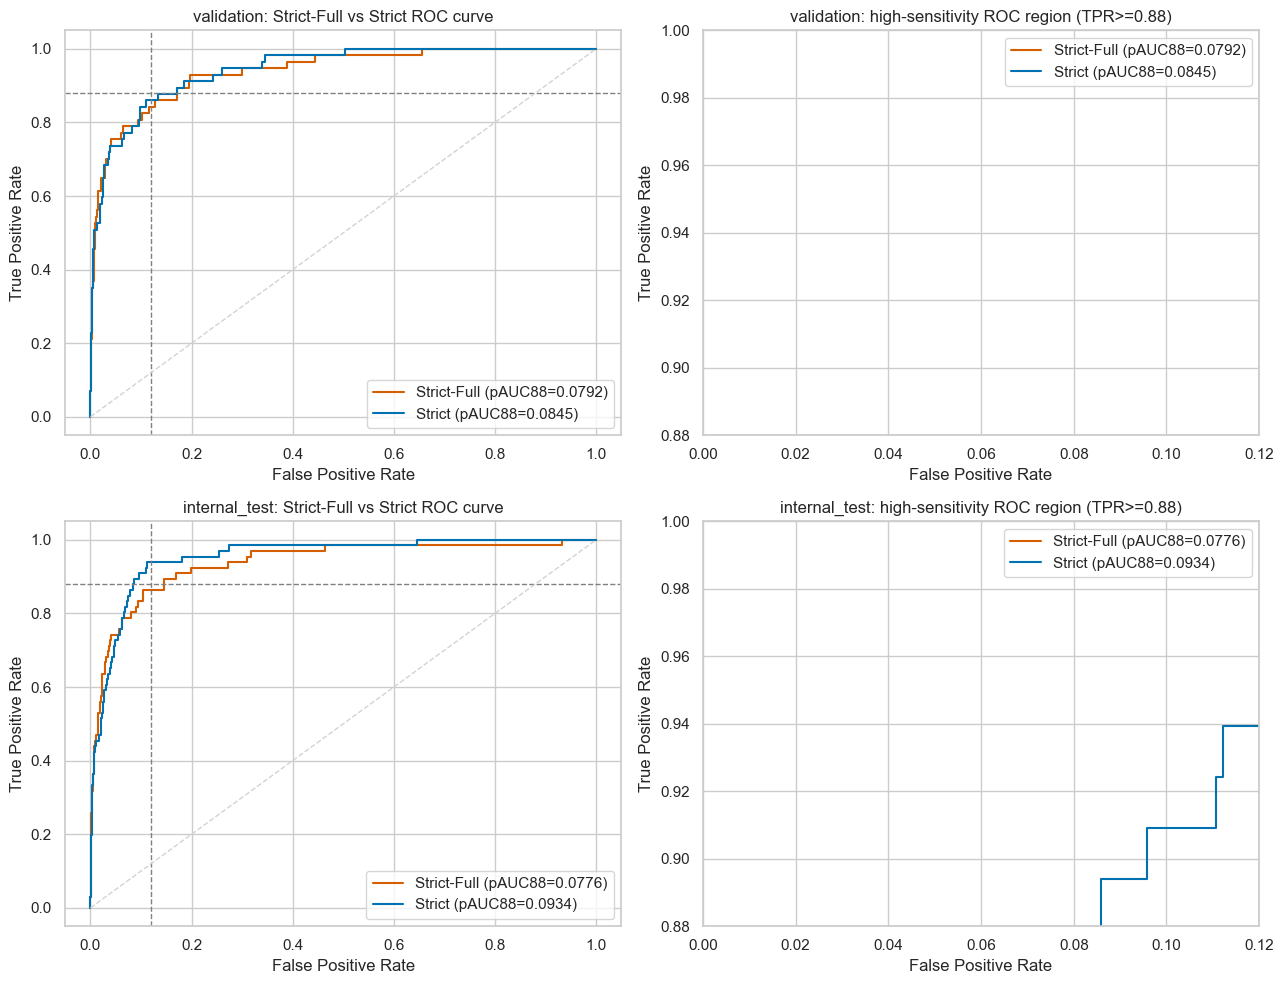

In [5]:
display_cols = [
    'regime_display', 'split', 'pauc_tpr88', 'pauc_tpr80', 'roc_auc', 'average_precision',
    'f1', 'recall', 'precision', 'specificity', 'balanced_accuracy',
    'threshold_from_validation_tpr88', 'validation_selected_tpr', 'validation_selected_specificity',
    'best_iteration', 'n_feature_columns'
]
display(comparison_metrics_df[display_cols].round(6))

pivot_df = comparison_metrics_df.pivot(index='split', columns='regime_display', values=['pauc_tpr88', 'pauc_tpr80', 'roc_auc', 'average_precision', 'f1', 'recall', 'precision'])
display(pivot_df.round(6))

rows = []
for split in comparison_metrics_df['split'].unique():
    full_row = comparison_metrics_df[(comparison_metrics_df['split'] == split) & (comparison_metrics_df['regime'] == 'strict_full')].iloc[0]
    final_row = comparison_metrics_df[(comparison_metrics_df['split'] == split) & (comparison_metrics_df['regime'] == 'final_strict')].iloc[0]
    rows.append({
        'split': split,
        'delta_pauc_tpr88_final_minus_full': final_row['pauc_tpr88'] - full_row['pauc_tpr88'],
        'delta_pauc_tpr80_final_minus_full': final_row['pauc_tpr80'] - full_row['pauc_tpr80'],
        'delta_roc_auc_final_minus_full': final_row['roc_auc'] - full_row['roc_auc'],
        'delta_average_precision_final_minus_full': final_row['average_precision'] - full_row['average_precision'],
        'delta_f1_final_minus_full': final_row['f1'] - full_row['f1'],
        'delta_recall_final_minus_full': final_row['recall'] - full_row['recall'],
        'delta_precision_final_minus_full': final_row['precision'] - full_row['precision'],
    })
comparison_delta_df = pd.DataFrame(rows)
display(comparison_delta_df.round(6))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for idx, split in enumerate(['validation', 'internal_test']):
    ax_roc = axes[idx, 0]
    ax_zoom = axes[idx, 1]
    for regime_name in ['strict_full', 'final_strict']:
        split_pred = comparison_predictions_df[(comparison_predictions_df['split'] == split) & (comparison_predictions_df['regime'] == regime_name)]
        y_true = split_pred['target'].to_numpy()
        y_prob = split_pred['pred_proba'].to_numpy()
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        pauc88 = p_auc_tpr(y_true, y_prob, PRIMARY_MIN_TPR)
        label = f"{DISPLAY_NAME.get(regime_name, regime_name)} (pAUC88={pauc88:.4f})"
        ax_roc.plot(fpr, tpr, label=label, color=DISPLAY_COLOR[regime_name])
        ax_zoom.plot(fpr, tpr, label=label, color=DISPLAY_COLOR[regime_name])

    for ax in [ax_roc, ax_zoom]:
        ax.axhline(PRIMARY_MIN_TPR, linestyle='--', color='gray', linewidth=1)
        ax.axvline(PRIMARY_MAX_FPR, linestyle='--', color='gray', linewidth=1)

    ax_roc.plot([0, 1], [0, 1], linestyle='--', color='lightgray', linewidth=1)
    ax_roc.set_title(f'{split}: Strict-Full vs Strict ROC curve')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend()

    ax_zoom.set_xlim(0, PRIMARY_MAX_FPR)
    ax_zoom.set_ylim(PRIMARY_MIN_TPR, 1.0)
    ax_zoom.set_title(f'{split}: high-sensitivity ROC region (TPR>=0.88)')
    ax_zoom.set_xlabel('False Positive Rate')
    ax_zoom.set_ylabel('True Positive Rate')
    ax_zoom.legend()

plt.tight_layout()
plt.show()


## 4. Strict-Full 전용 feature 11개의 중요도 확인

### 목적
코드 셀에서는 `Strict-Full` 모델 안에서, 추가 11개 feature가 어느 정도 중요도로 쓰였는지 먼저 확인합니다.

중요도는 ablation 결과와 함께 읽어야 합니다.
어떤 feature가 중요도가 높아 보여도, 제거했을 때 `pAUC@TPR>=0.88`이 오르면 실제로는 불안정한 feature일 수 있습니다.


,regime,regime_display,model_tag,feature,importance
7,strict_full,Strict-Full,catboost_baseline,feat_hue_circular_gap,2.992061
12,strict_full,Strict-Full,catboost_baseline,feat_nevi_border_interaction,2.479172
15,strict_full,Strict-Full,catboost_baseline,feat_xz_radius,2.287227
18,strict_full,Strict-Full,catboost_baseline,feat_age_contrast_interaction,2.135535
29,strict_full,Strict-Full,catboost_baseline,feat_long_to_minor_ratio,1.429283
40,strict_full,Strict-Full,catboost_baseline,feat_red_green_normalized_gap,0.846948
50,strict_full,Strict-Full,catboost_baseline,feat_perimeter_to_long_ratio,0.487324
52,strict_full,Strict-Full,catboost_baseline,feat_color_to_border_ratio,0.398557
53,strict_full,Strict-Full,catboost_baseline,feat_contrast_to_color_variation,0.372863
55,strict_full,Strict-Full,catboost_baseline,feat_diameter_symmetry_coupling,0.323148


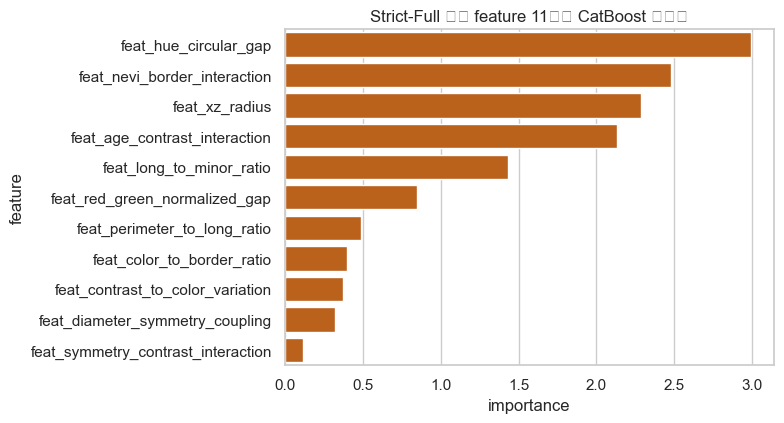

In [6]:
strict_only_importance_df = comparison_importance_df[
    (comparison_importance_df['regime'] == 'strict_full')
    & (comparison_importance_df['feature'].isin(strict_only_features))
].copy().sort_values('importance', ascending=False)

display(strict_only_importance_df.round(6))

plt.figure(figsize=(8, max(4, len(strict_only_importance_df) * 0.4)))
sns.barplot(data=strict_only_importance_df, y='feature', x='importance', color=DISPLAY_COLOR['strict_full'])
plt.title('Strict-Full 전용 feature 11개의 CatBoost 중요도')
plt.xlabel('importance')
plt.ylabel('feature')
plt.tight_layout()
plt.show()


## 5. Strict-Full 전용 feature 단일 제거 ablation

### 목적
코드 셀에서는 `Strict-Full`에만 있는 추가 feature 11개를 **하나씩 제거한 모델**을 다시 학습합니다.

판단 방식:
1. 어떤 feature를 제거했을 때 `internal_test`의 `pAUC@TPR>=0.88`이 올라가면, 그 feature는 현재 조합에서 성능을 해칠 가능성이 있습니다.
2. 반대로 제거했을 때 `pAUC@TPR>=0.88`이 내려가면, 그 feature는 유지 가치가 있는 후보입니다.
3. `Average Precision`, `ROC AUC`는 보조로 함께 봅니다.

이번 단계는 `Strict-Full`이 왜 `Strict`보다 약한가를 더 구체적으로 해부하는 단계입니다.


In [7]:
strict_full_train = strict_full_data['train'].copy()
strict_full_val = strict_full_data['validation'].copy()
strict_full_test = strict_full_data['internal_test'].copy()
strict_full_features = [c for c in strict_full_train.columns if c not in meta_cols]

ablation_metric_rows = []
ablation_importance_frames = []

full_strict_metrics = comparison_metrics_df[(comparison_metrics_df['regime'] == 'strict_full')].copy()
full_strict_metrics['dropped_feature'] = 'none'
ablation_metric_rows.append(full_strict_metrics)

for dropped_feature in strict_only_features:
    feature_cols = [c for c in strict_full_features if c != dropped_feature]
    result = fit_and_score(
        regime_name='strict_full_ablation',
        train_df=strict_full_train,
        val_df=strict_full_val,
        test_df=strict_full_test,
        feature_cols=feature_cols,
        model_tag=f'drop__{dropped_feature}',
    )
    metrics_df = pd.DataFrame(result['metric_rows'])
    metrics_df['dropped_feature'] = dropped_feature
    ablation_metric_rows.append(metrics_df)

    fi_df = result['feature_importance'].copy()
    fi_df['dropped_feature'] = dropped_feature
    ablation_importance_frames.append(fi_df)

ablation_metrics_df = pd.concat(ablation_metric_rows, ignore_index=True)
ablation_importance_df = pd.concat(ablation_importance_frames, ignore_index=True)

ablation_metrics_path = out_dir / 'strict_only_feature_ablation_metrics.csv'
ablation_importance_path = out_dir / 'strict_only_feature_ablation_feature_importance.csv'
ablation_metrics_df.to_csv(ablation_metrics_path, index=False)
ablation_importance_df.to_csv(ablation_importance_path, index=False)

print('saved ->', ablation_metrics_path)
print('saved ->', ablation_importance_path)
display(ablation_metrics_df.head().round(6))
print('total ablation runs =', ablation_metrics_df['dropped_feature'].nunique())


saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_catboost_ablation/strict_only_feature_ablation_metrics.csv
saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_catboost_ablation/strict_only_feature_ablation_feature_importance.csv


,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,log_loss,brier_score,precision,recall,f1,balanced_accuracy,...,model_tag,split,threshold_from_validation_tpr88,validation_selected_tpr,validation_selected_specificity,best_iteration,n_rows,n_positive_rows,n_feature_columns,dropped_feature
0,0.079219,0.149047,0.938436,0.067758,0.207609,0.057760,0.004509,0.894737,0.008973,0.861588,...,catboost_baseline,validation,0.281905,0.894737,0.828440,68,65684,57,62,none
1,0.077608,0.149040,0.936958,0.081565,0.202385,0.055978,0.006474,0.893939,0.012855,0.864622,...,catboost_baseline,internal_test,0.281905,0.894737,0.828440,68,55040,66,62,none
2,0.075923,0.146381,0.935694,0.060318,0.231986,0.063544,0.004901,0.894737,0.009748,0.868468,...,drop__feat_age_contrast_interaction,validation,0.323412,0.894737,0.842199,52,65684,57,61,feat_age_contrast_interaction
3,0.078124,0.150648,0.936509,0.102684,0.234699,0.064905,0.006873,0.924242,0.013645,0.881956,...,drop__feat_age_contrast_interaction,internal_test,0.323412,0.894737,0.842199,52,55040,66,61,feat_age_contrast_interaction
4,0.071840,0.142047,0.927243,0.057824,0.221113,0.061630,0.003236,0.894737,0.006448,0.827669,...,drop__feat_color_to_border_ratio,validation,0.210308,0.894737,0.760602,59,65684,57,61,feat_color_to_border_ratio


total ablation runs = 12


## 6. Ablation 결과 정리: 어떤 feature가 pAUC@88을 해치는가?

### 목적
코드 셀에서는 `Strict-Full`을 기준으로, 각 feature를 제거했을 때 성능이 얼마나 바뀌는지 `delta`로 계산합니다.

해석 기준:
1. `delta_pauc_tpr88 > 0`이면, 그 feature를 제거했을 때 기본 평가지표가 올라간 것입니다.
2. 특히 `internal_test`에서 `pAUC@TPR>=0.88`과 `Average Precision`이 같이 올라가면, 그 feature는 해로운 후보로 볼 수 있습니다.
3. 반대로 `delta_pauc_tpr88 < 0`이면, 제거했을 때 성능이 내려가므로 유지 가치가 있는 feature입니다.


saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_catboost_ablation/strict_only_feature_ablation_delta.csv
internal_test 기준: 제거 시 pAUC@88이 가장 좋아지는 feature


,dropped_feature,split,pauc_tpr88_after_drop,pauc_tpr80_after_drop,average_precision_after_drop,roc_auc_after_drop,delta_pauc_tpr88,delta_pauc_tpr80,delta_average_precision,delta_roc_auc
17,feat_red_green_normalized_gap,internal_test,0.081234,0.154566,0.105234,0.940499,0.003627,0.005526,0.023669,0.003541
9,feat_hue_circular_gap,internal_test,0.078645,0.150756,0.099360,0.936701,0.001037,0.001716,0.017795,-0.000257
11,feat_long_to_minor_ratio,internal_test,0.078593,0.146603,0.078199,0.930988,0.000986,-0.002437,-0.003366,-0.005969
1,feat_age_contrast_interaction,internal_test,0.078124,0.150648,0.102684,0.936509,0.000516,0.001608,0.021119,-0.000449
13,feat_nevi_border_interaction,internal_test,0.076174,0.147064,0.074114,0.933316,-0.001434,-0.001976,-0.007450,-0.003642
7,feat_diameter_symmetry_coupling,internal_test,0.075716,0.148815,0.087284,0.935603,-0.001892,-0.000224,0.005719,-0.001354
19,feat_symmetry_contrast_interaction,internal_test,0.075169,0.146979,0.102149,0.933303,-0.002439,-0.002061,0.020584,-0.003654
21,feat_xz_radius,internal_test,0.074748,0.147250,0.096594,0.933391,-0.002860,-0.001789,0.015029,-0.003566
5,feat_contrast_to_color_variation,internal_test,0.073410,0.145994,0.094254,0.933476,-0.004198,-0.003046,0.012689,-0.003482
15,feat_perimeter_to_long_ratio,internal_test,0.071004,0.144071,0.103716,0.930602,-0.006603,-0.004968,0.022152,-0.006355


validation 기준: 제거 시 pAUC@88이 가장 좋아지는 feature


,dropped_feature,split,pauc_tpr88_after_drop,pauc_tpr80_after_drop,average_precision_after_drop,roc_auc_after_drop,delta_pauc_tpr88,delta_pauc_tpr80,delta_average_precision,delta_roc_auc
8,feat_hue_circular_gap,validation,0.086721,0.157716,0.068015,0.944472,0.007502,0.008669,0.000257,0.006036
6,feat_diameter_symmetry_coupling,validation,0.082684,0.155071,0.070179,0.942363,0.003466,0.006024,0.002422,0.003927
16,feat_red_green_normalized_gap,validation,0.078635,0.149184,0.076274,0.939409,-0.000583,0.000137,0.008517,0.000973
14,feat_perimeter_to_long_ratio,validation,0.077953,0.147800,0.067899,0.936139,-0.001265,-0.001247,0.000142,-0.002297
20,feat_xz_radius,validation,0.076544,0.147207,0.067373,0.935675,-0.002674,-0.001840,-0.000385,-0.002761
10,feat_long_to_minor_ratio,validation,0.076139,0.145633,0.064987,0.935402,-0.003079,-0.003414,-0.002770,-0.003034
0,feat_age_contrast_interaction,validation,0.075923,0.146381,0.060318,0.935694,-0.003295,-0.002666,-0.007439,-0.002742
4,feat_contrast_to_color_variation,validation,0.073989,0.145459,0.068112,0.934555,-0.005230,-0.003589,0.000354,-0.003881
2,feat_color_to_border_ratio,validation,0.071840,0.142047,0.057824,0.927243,-0.007379,-0.007000,-0.009934,-0.011193
18,feat_symmetry_contrast_interaction,validation,0.070070,0.140448,0.064706,0.928978,-0.009149,-0.008600,-0.003052,-0.009458


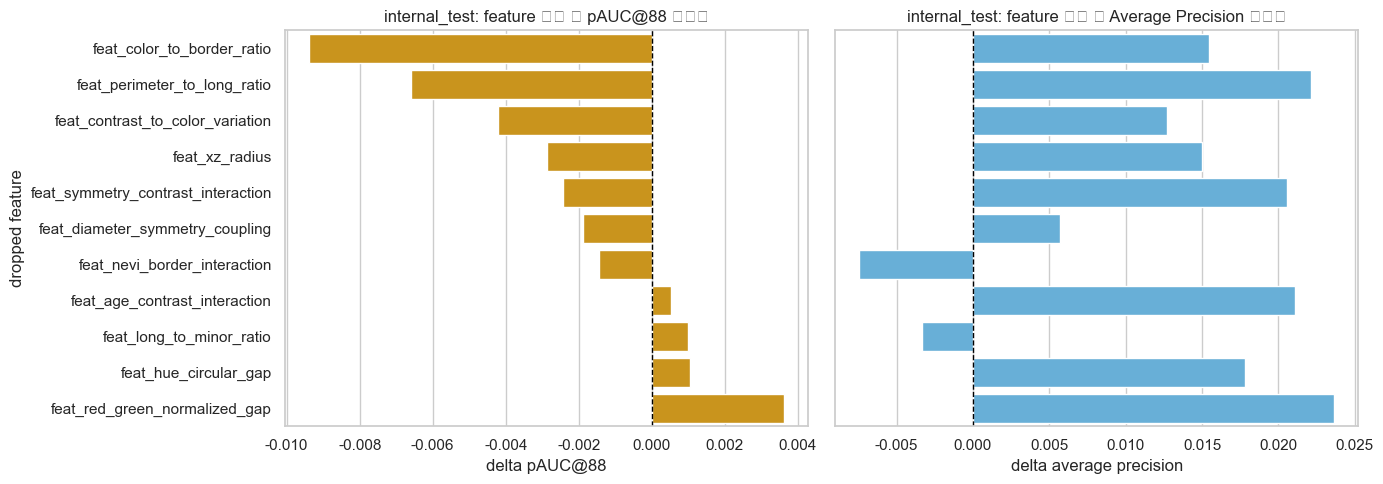

In [8]:
baseline_df = ablation_metrics_df[ablation_metrics_df['dropped_feature'] == 'none'].copy()
rows = []
for dropped_feature in strict_only_features:
    candidate_df = ablation_metrics_df[ablation_metrics_df['dropped_feature'] == dropped_feature]
    for split in ['validation', 'internal_test']:
        base_row = baseline_df[baseline_df['split'] == split].iloc[0]
        cand_row = candidate_df[candidate_df['split'] == split].iloc[0]
        rows.append({
            'dropped_feature': dropped_feature,
            'split': split,
            'pauc_tpr88_after_drop': cand_row['pauc_tpr88'],
            'pauc_tpr80_after_drop': cand_row['pauc_tpr80'],
            'average_precision_after_drop': cand_row['average_precision'],
            'roc_auc_after_drop': cand_row['roc_auc'],
            'delta_pauc_tpr88': cand_row['pauc_tpr88'] - base_row['pauc_tpr88'],
            'delta_pauc_tpr80': cand_row['pauc_tpr80'] - base_row['pauc_tpr80'],
            'delta_average_precision': cand_row['average_precision'] - base_row['average_precision'],
            'delta_roc_auc': cand_row['roc_auc'] - base_row['roc_auc'],
        })

ablation_delta_df = pd.DataFrame(rows)
ablation_delta_path = out_dir / 'strict_only_feature_ablation_delta.csv'
ablation_delta_df.to_csv(ablation_delta_path, index=False)
print('saved ->', ablation_delta_path)

internal_test_delta_df = ablation_delta_df[ablation_delta_df['split'] == 'internal_test'].copy()
internal_test_delta_df = internal_test_delta_df.sort_values(['delta_pauc_tpr88', 'delta_average_precision'], ascending=False)
validation_delta_df = ablation_delta_df[ablation_delta_df['split'] == 'validation'].copy()
validation_delta_df = validation_delta_df.sort_values(['delta_pauc_tpr88', 'delta_average_precision'], ascending=False)

print('internal_test 기준: 제거 시 pAUC@88이 가장 좋아지는 feature')
display(internal_test_delta_df.round(6))

print('validation 기준: 제거 시 pAUC@88이 가장 좋아지는 feature')
display(validation_delta_df.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(strict_only_features) * 0.45)), sharey=True)
plot_df = internal_test_delta_df.sort_values('delta_pauc_tpr88', ascending=True)
sns.barplot(data=plot_df, y='dropped_feature', x='delta_pauc_tpr88', color='#E69F00', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('internal_test: feature 제거 시 pAUC@88 변화량')
axes[0].set_xlabel('delta pAUC@88')
axes[0].set_ylabel('dropped feature')

sns.barplot(data=plot_df, y='dropped_feature', x='delta_average_precision', color='#56B4E9', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('internal_test: feature 제거 시 Average Precision 변화량')
axes[1].set_xlabel('delta average precision')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 해석 포인트
1. 막대가 `0`보다 오른쪽이면, 그 feature를 제거했을 때 성능이 좋아진 것입니다.
2. 가장 먼저 `pAUC@TPR>=0.88`을 보고, 그 다음 `Average Precision`을 함께 봅니다.
3. 두 지표가 같이 개선되는 feature는 특히 의심해볼 만합니다.


## 7. 결론 정리

이 노트북을 통해 아래 질문에 답할 수 있습니다.
1. Tree 기반 모델에서도 `Strict-Full`이 `Strict`보다 좋은가?
2. 아니라면, 추가 11개 feature 중 어떤 feature가 높은 민감도 구간의 성능을 실제로 깎는가?
3. 이후 `Strict-Pruned`를 만들 때 어떤 feature를 제거 후보로 삼아야 하는가?

다음 단계 제안:
1. `internal_test`에서 일관되게 해로운 feature를 제거한 `Strict-Pruned` 세트 만들기
2. 같은 pruning 결과를 `LogisticRegression`과 `CatBoost`에서 공통으로 확인하기
3. 오분류 샘플을 기준으로 `Strict-Full`과 `Strict`의 실패 패턴 차이 분석하기
